In [1]:
import pandas as pd
import numpy as np
# import cugraph
import glob
import matplotlib.pyplot as plt 
from multiprocessing import Pool
from ast import literal_eval
import swifter
import networkx as nx
import netwulf as nw
from netwulf import visualize
import netwulf as nw
from pandarallel import pandarallel
# import cugraph

import zipfile
import pandas as pd
import os
import glob
from functions import *
from ast import literal_eval
from multiprocessing import Pool
import numpy as np
from collections import Counter

from ast import literal_eval
import tldextract

In [16]:
pandarallel.initialize(progress_bar=True, nb_workers=10)

INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [2]:
df = pd.read_pickle("/media/herbert/Extreme_Pro/AVAX/Processed_Data/provax-hashtags.pkl")

In [35]:
filter_list = set(["vaccine", "cdnpoli", "elxn44", "getvaccinated","pandemic","wearamask","auspol","auschwitz","publichealth",
              "corona", "johnsonout","china","globalhealth","health"])

In [4]:
df1 = df[~df.hashtag.str.contains("covid|coronavirus|sarscov2|deltavariant|breaking|afghanistan")]
df1 = df1[~df1.hashtag.str.contains("|".join(filter_list))]

In [9]:
climateChange = ["climatechange","climatecrisis","science"]
ai = ["ai","rstats","datascience","machinelearning", "bigdata"]
events  = ["tokyo2020"]
disease = ["ebola", "hiv", "malaria"] 
provax = ["getvaccinated", "vaccineswork", "thisisourshot", 
               "vaccineequity", "peoplesvaccine", 
              "vaccinessavelives",]

In [10]:
hashset = climateChange + ai +events +disease + provax

## Extract

In [13]:
def read_subset(p):
    f = p
    df = pd.read_pickle(f)
    df = df[["userid", "text", "rt_userid", "date", "hashtag", "state"]]
    df.hashtag = df.hashtag.apply(literal_eval)
    # df = df[df.hashtag.apply(lambda x: len(x) > 1)] 
    # provax_ind = df.hashtag.apply(lambda x: len(set(x) & provax) > 0 )
    return df

In [14]:
%%time
path = "/media/herbert/Extreme_Pro/AVAX/Processed_Data/RT_hashtag_nets/provax2/*"
if __name__ == "__main__":
    pool = Pool(24)
    df = pool.map(read_subset, glob.glob(path))
    pool.close()
    pool.join()

CPU times: user 12.5 s, sys: 2.84 s, total: 15.3 s
Wall time: 1min 46s


In [15]:
df = pd.concat(df)

In [17]:
df.hashtag = df.hashtag.parallel_apply(lambda x: set([y.lower() for y in x]))

In [18]:
climateChange = ["climatechange","climatecrisis"]
ai = ["ai","rstats","datascience","machinelearning", "bigdata"]
events  = ["tokyo2020"]
disease = ["ebola", "hiv", "malaria"] 
provax = ["getvaccinated", "vaccineswork", "thisisourshot", "vaccineswork", 
               "vaccineequity", "peoplesvaccine", 
              "vaccinessavelives",]

In [19]:
def get_set(x):
    search_set = set( x )
    return df.hashtag.apply(lambda x: len( x & search_set ) > 0)

In [20]:
df["climate"] = get_set(climateChange)
df["tokyo"]   = get_set(events)
df["disease"] = get_set(disease)
df["provax"]  = get_set(provax)
df["ai"]      = get_set(ai)

In [21]:
def extract_network(hash2, thresh=2):
    df1 = df[ df.provax | df[hash2] ]
    e,f = np.unique( df1[["userid","rt_userid"]].values , return_counts=True, axis=0)
    E = np.hstack((e,np.atleast_2d( f ).T))
    E = pd.DataFrame(E, columns = ["u1", "u2", "w"])
    e,uniq = pd.factorize(np.hstack((E.u1, E.u2)))
    E.u1 , E.u2 = e[:int(len(e)/2)], e[int(len(e)/2):] 
    EE = E[E.w > thresh]
    return EE, uniq, df1

## Overlap

In [307]:
# %%time
MC_NUM = 100
steps  = 400

ex = []

for hash2 in ["climate", "tokyo", "disease","ai"]:
    EE,uniq, df1 = extract_network(hash2)
    
    # df1 = df[ df.provax | df[hash2] ]
    grp1 = set( df1[ df1.provax ].userid.tolist() + df1[ df1.provax ].rt_userid.tolist())
    grp2 = set( df1[ df1[hash2] ].userid.tolist() + df1[ df1[hash2] ].rt_userid.tolist())

    GG = nx.Graph()
    GG.add_weighted_edges_from(EE.values)

    A = nx.to_numpy_array(GG,dtype=bool)
    inf_og = np.array([(uniq[n] in grp1) for n in GG.nodes()])
    deg = np.array([GG.degree()[n] for n in GG.nodes()])

    df1 = pd.DataFrame()
    df1["hash2"] = [hash2]*MC_NUM
    df1["params"] = [[A,inf_og,deg]]*MC_NUM

    ex.append(df1)
ex = pd.concat(ex)

In [308]:
pandarallel.initialize(progress_bar=True, nb_workers=24)

INFO: Pandarallel will run on 24 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [309]:
ex = ex.sample(frac=1.0)

In [311]:
def simulate_diffusion(p):
    A, inf_og, deg = p
    inf = inf_og.copy()
    inf_count = np.zeros(steps+1)
    inf_count[0] = inf.sum()
    
    for i in range(steps):
        cands = (A * inf).sum(axis=1) # Number of viable candidates
        prop = cands / deg  # Proportion of neighbors infected
        prop_adj = prop * (1-inf) # Remove those already converted
        delta = np.random.rand(len(inf)) < (prop_adj*0.05)
        inf += delta
        inf_count[i+1] = inf.sum()
    return inf_count

In [312]:
%%time
ex["ts"] = ex.params.parallel_apply(simulate_diffusion)

CPU times: user 603 ms, sys: 10.8 s, total: 11.4 s
Wall time: 16min 42s


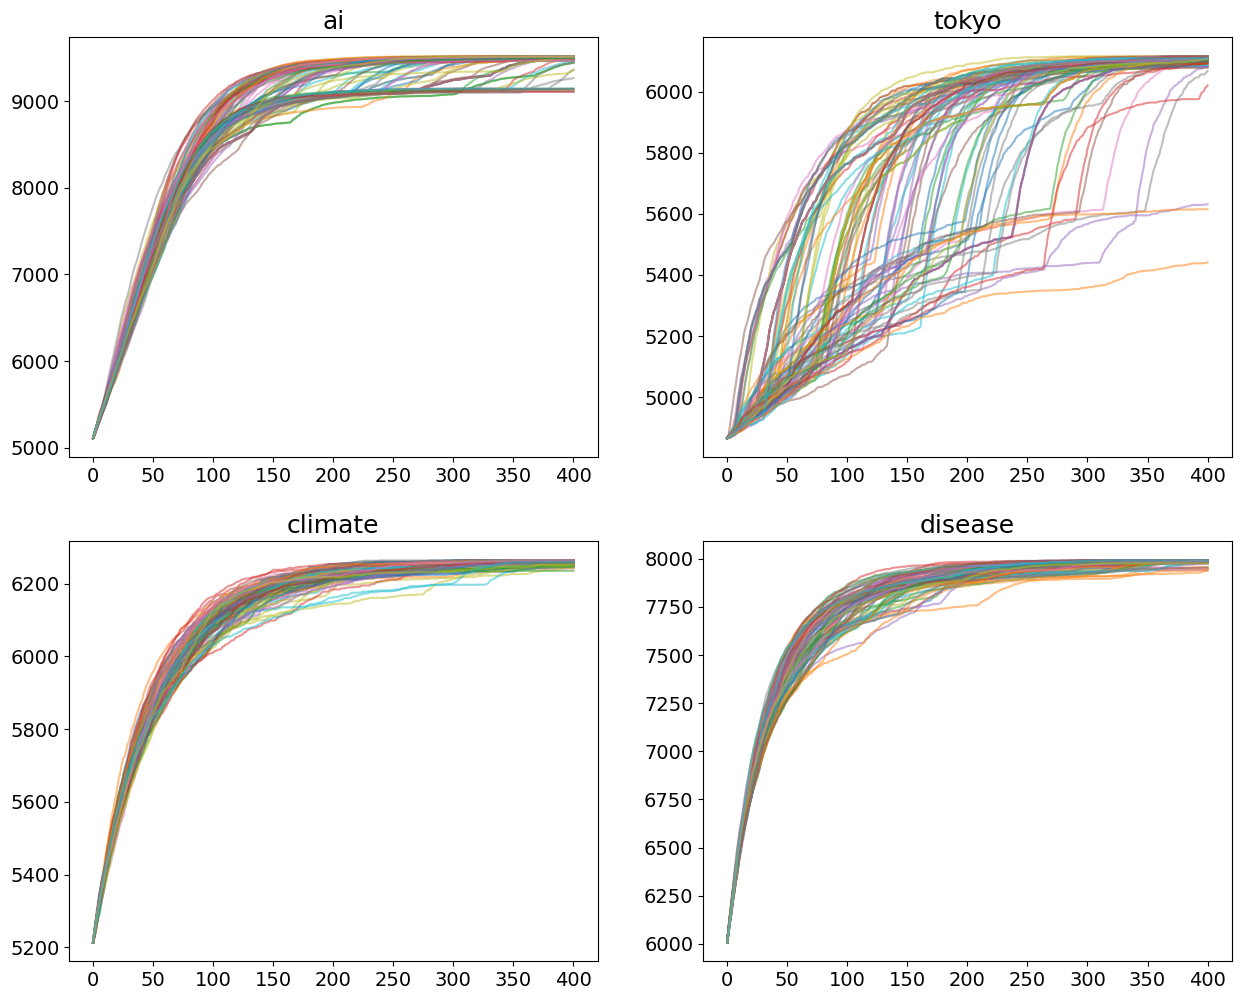

In [420]:
plt.figure(figsize=(15,12))
for i,ht in enumerate(ex.hash2.unique()):
    ex1 = ex[ex.hash2 == ht]
    # plt.figure()
    plt.subplot(2,2,i+1)
    plt.title(ht, fontsize=18)
    ts = np.vstack( ex1.ts.values )
    for t in ts:
        plt.plot( t , alpha = 0.5)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

plt.savefig("diffusion_group.png")

In [375]:
steps

400

In [416]:
def simulate_diffusion_dormancy(p):
    A, inf_og, deg = p
    inf = inf_og.copy()
    inf_count = np.zeros(steps+1)
    inf_count[0] = inf.sum()
    
    dorm   = (np.random.rand(len(inf)) < dorm_rate)*inf # only ones that are infected are excluded
    
    for i in range(steps):
        dorm_delta   = (np.random.rand(len(inf)) < dorm_rate)*inf
        dorm += dorm_delta
        viable = inf * (1-dorm)
        
        cands = (A * viable).sum(axis=1) # for those viable to be bconverted.\
        prop = cands / deg 
        prop_adj = prop * (1-inf)
        delta = np.random.rand(len(inf)) < (prop_adj*0.05)
        inf += delta
        inf_count[i+1] = inf.sum()
    return inf_count

In [1]:
%%time
ex["ts_dorm"] = ex.params.parallel_apply(simulate_diffusion_dormancy)

In [423]:
ex.to_pickle("simulations_group.pkl", compression="bz2")

In [417]:
%%time
simulate_diffusion_dormancy(ex.params.iloc[0])

CPU times: user 44 s, sys: 25.3 s, total: 1min 9s
Wall time: 1min 9s


array([5111., 5155., 5201., 5235., 5273., 5307., 5350., 5399., 5444.,
       5496., 5540., 5581., 5620., 5664., 5718., 5762., 5801., 5845.,
       5874., 5920., 5960., 6006., 6052., 6091., 6130., 6162., 6211.,
       6243., 6284., 6321., 6357., 6397., 6436., 6474., 6509., 6543.,
       6572., 6606., 6651., 6691., 6728., 6763., 6806., 6835., 6874.,
       6912., 6946., 6971., 7009., 7034., 7056., 7082., 7102., 7122.,
       7143., 7168., 7186., 7200., 7223., 7235., 7251., 7270., 7294.,
       7318., 7338., 7362., 7387., 7408., 7434., 7460., 7483., 7506.,
       7525., 7545., 7563., 7580., 7591., 7612., 7633., 7657., 7672.,
       7688., 7706., 7724., 7738., 7748., 7757., 7768., 7779., 7785.,
       7794., 7811., 7818., 7827., 7840., 7853., 7864., 7876., 7887.,
       7896., 7903., 7909., 7921., 7933., 7944., 7950., 7956., 7962.,
       7969., 7977., 7986., 7993., 7996., 8006., 8019., 8024., 8032.,
       8038., 8043., 8058., 8077., 8088., 8107., 8112., 8127., 8152.,
       8164., 8183.,

## Iterate through hashtags

In [5]:
def extract_network_single_ht_search(hash2, thresh=2):
    
    df1 = df[ df.provax | df.hashtag.apply(lambda x: hash2 in x) ].copy() # need convert to 
    df1["hash2"] = df1.hashtag.apply(lambda x: hash2 in x)
    
    e,f = np.unique( df1[["userid","rt_userid"]].values , return_counts=True, axis=0)
    E = np.hstack((e,np.atleast_2d( f ).T))
    E = pd.DataFrame(E, columns = ["u1", "u2", "w"])
    e,uniq = pd.factorize(np.hstack((E.u1, E.u2)))
    E.u1 , E.u2 = e[:int(len(e)/2)], e[int(len(e)/2):]
    # G = nx.Graph()
    # G.add_weighted_edges_from(E.values)  
    EE = E[E.w > thresh]
    return EE, uniq, df1

In [27]:
from collections import Counter
flat_list = [x for xs in df.hashtag for x in xs]
top_hash = Counter(flat_list)

In [34]:
top_hash.most_common(200)

[('covid19', 1206335),
 ('ai', 341465),
 ('covid', 306303),
 ('passsanitaire', 300570),
 ('valimai', 255740),
 ('coronavirus', 238931),
 ('machinelearning', 226274),
 ('datascience', 215960),
 ('satyagrah_againstexamsincovid', 191709),
 ('getvaccinated', 182684),
 ('ukraine', 178278),
 ('shanghai', 165571),
 ('python', 163282),
 ('taiwan', 150955),
 ('thailand', 144698),
 ('mumbai', 136177),
 ('protestagainstexamsincovid', 128836),
 ('jaipur', 103457),
 ('100daysofcode', 90957),
 ('iot', 88366),
 ('corona', 87712),
 ('chennai', 87145),
 ('bbnaija', 86522),
 ('tokyo2020', 86166),
 ('bigdata', 84194),
 ('china', 83473),
 ('lockdown', 82053),
 ('climatechange', 81397),
 ('blood', 81176),
 ('hiv', 71744),
 ('wearamask', 66976),
 ('science', 65441),
 ('rajasthan', 61608),
 ('ebola', 58189),
 ('coronaupdate', 57810),
 ('recovered', 53968),
 ('ajithkumar', 52218),
 ('covidisairborne', 48193),
 ('pandemic', 47989),
 ('bloodaid', 47546),
 ('speakupforsscrailwaysstudends', 45978),
 ('vaccineswor

In [36]:
# %%time
MC_NUM = 100
steps  = 400

ex2 = []

for i, (k,v) in enumerate(top_hash.most_common(200)):

    if i ==0:
        continue
    
    EE,uniq, df1 = extract_network_single_ht_search(k)
    
    # df1 = df[ df.provax | df[hash2] ]
    grp1 = set( df1[ df1.provax ].userid.tolist() + df1[ df1.provax ].rt_userid.tolist())
    grp2 = set( df1[ df1["hash2"] ].userid.tolist() + df1[ df1["hash2"] ].rt_userid.tolist())

    GG = nx.Graph()
    GG.add_weighted_edges_from(EE.values)

    A = nx.to_numpy_array(GG,dtype=bool)
    inf_og = np.array([(uniq[n] in grp1) for n in GG.nodes()])
    deg = np.array([GG.degree()[n] for n in GG.nodes()])

    df1 = pd.DataFrame()
    df1["hash2"] = [k]*MC_NUM
    df1["params"] = [[A,inf_og,deg]]*MC_NUM

    ex2.append(df1)

    if i ==200:
        break
        
ex2 = pd.concat(ex2)

In [ ]:
ex2 = ex2[ex2.hash2 != "covid"]

In [ ]:
%%time
ex2["ts_dorm"] = ex2.params.parallel_apply(simulate_diffusion_dormancy)

In [40]:
ex2.to_pickle("indv_hashtag_simulations_2.pkl", compression="bz2")